# Particle Filter Testing

Tests across three state-space models:
1. `SimpleLinearGaussianSSM` — single filter run, MC RMSE distribution, noise sensitivity, resampling method comparison
2. `LinearTSSM` — correct vs misspecified (Gaussian) filter on t-distributed data
3. `LinearARMASSM` — filter on ARMA(1,3) latent process

In [10]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from models.linear_gaussian import SimpleLinearGaussianSSM
from models.linear_t import LinearTSSM
from models.linear_ARMA import LinearARMASSM
from estimation.particle_filter import ParticleFilter
from estimation.resampling_methods import (
    SystematicResampling, MultinomialResampling, ResidualResampling, StratifiedResampling
)
from utils import filtered_trajectory, ess_trajectory, rmse

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

---
## 1. SimpleLinearGaussianSSM — single run

In [3]:
# true params
phi_true = 0.9
alpha_true = 1.5
sigma_true = 0.5
tau_true = 1.0

model = SimpleLinearGaussianSSM(phi=phi_true, alpha=alpha_true, sigma=sigma_true, tau=tau_true, seed=42)
print(model)

T = 200
states, observations, true_loglik = model.generate_data(T)
# states/observations: (T, 1) — flatten for PF
obs_1d = observations[:, 0]
true_x  = states[:, 0]

pf = ParticleFilter(
    model=model, N_particles=2000, data=obs_1d,
    resample_method=SystematicResampling(seed=0)
)
_, ph, wh, rsh, loglik = pf.run_filter()

x_hat = filtered_trajectory(pf)
print(f"True log-lik : {float(np.squeeze(true_loglik)):.2f}")
print(f"PF  log-lik  : {loglik:.2f}")
print(f"RMSE         : {rmse(true_x, x_hat):.4f}")
print(f"Resample steps: {sum(rsh)} / {T}")

SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma=0.5, tau=1.0)
True log-lik : -267.41
PF  log-lik  : -367.67
RMSE         : 0.4371
Resample steps: 48 / 200


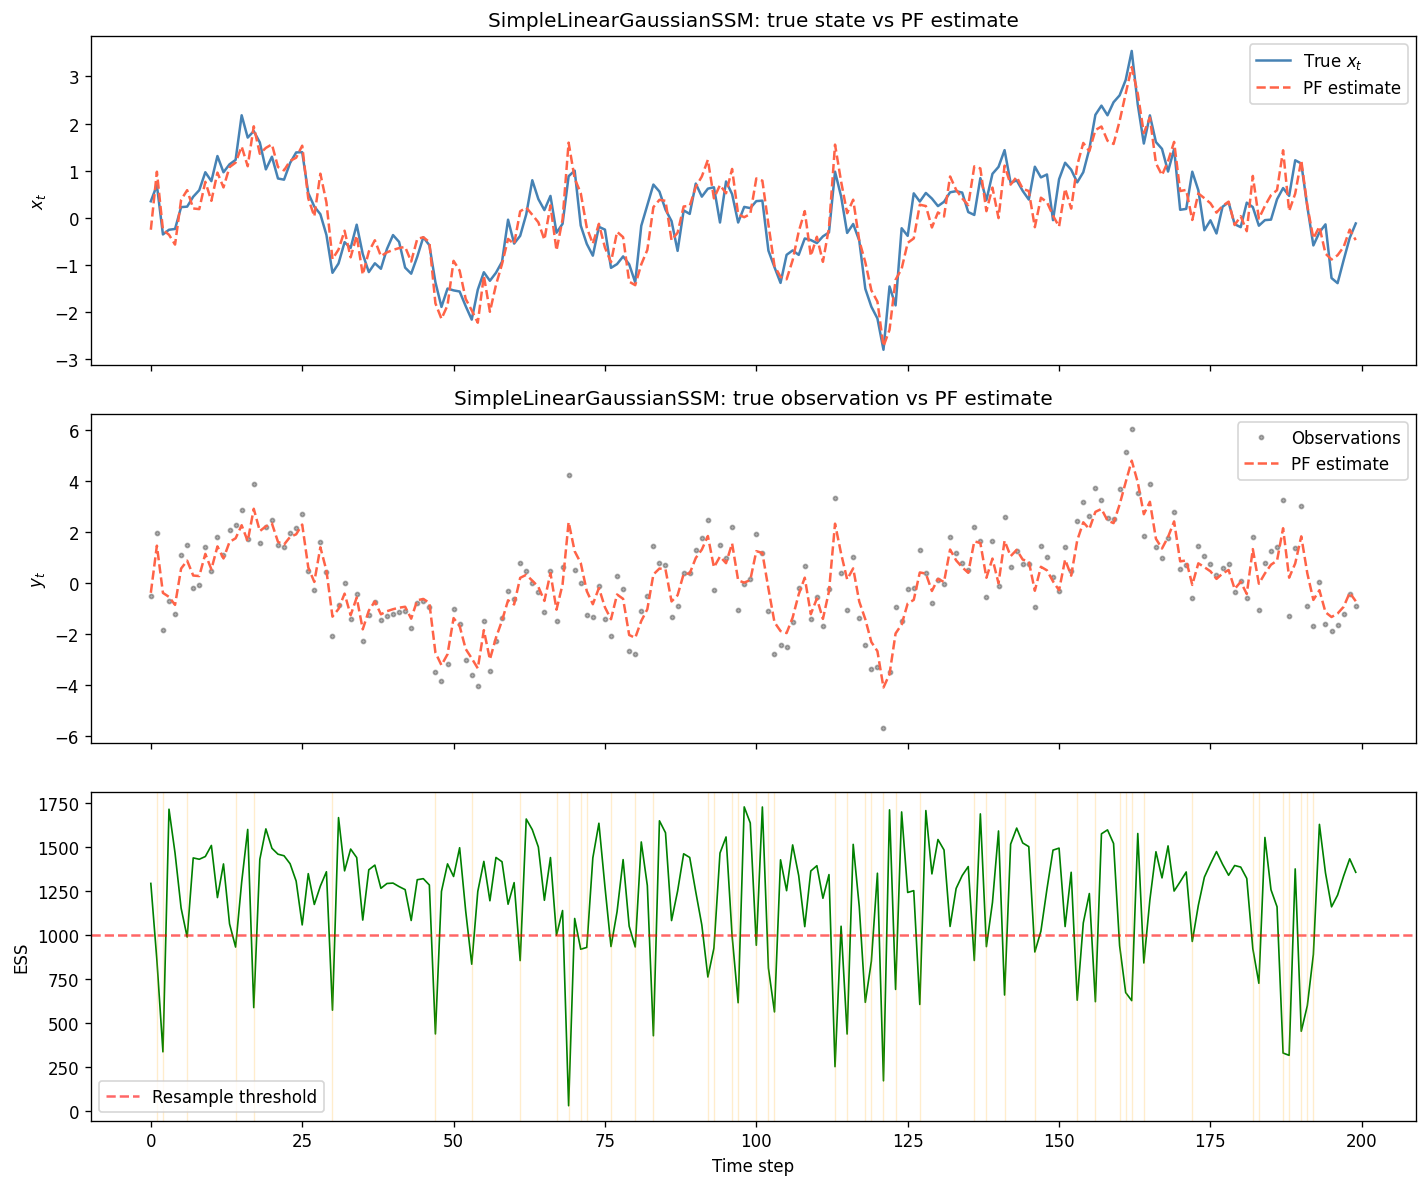

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(true_x, label='True $x_t$', color='steelblue', lw=1.5)
axes[0].plot(x_hat,  label='PF estimate', color='tomato', lw=1.5, linestyle='--')
axes[0].set_ylabel('$x_t$')
axes[0].legend()
axes[0].set_title('SimpleLinearGaussianSSM: true state vs PF estimate')

axes[1].plot(obs_1d, '.', color='black', markersize=5, alpha=0.3, label='Observations')
axes[1].plot(alpha_true * x_hat, label='PF estimate', color='tomato', lw=1.5, linestyle='--')
axes[1].set_ylabel('$y_t$')
axes[1].legend()
axes[1].set_title('SimpleLinearGaussianSSM: true observation vs PF estimate')

ess = ess_trajectory(pf)
axes[2].plot(ess, color='green', lw=1)
axes[2].axhline(pf.resample_threshold * pf.N_particles, color='red',
                linestyle='--', alpha=0.6, label='Resample threshold')
for s in [i for i, r in enumerate(rsh) if r]:
    axes[2].axvline(s, color='orange', alpha=0.2, lw=0.8)
axes[2].set_ylabel('ESS')
axes[2].set_xlabel('Time step')
axes[2].legend()
plt.tight_layout()
plt.show()

---
## 2. MC RMSE and log-likelihood distribution (50 trials)

In [5]:
N_trials = 50
T_mc = 150
N_mc  = 1000

rmse_mc   = []
loglik_mc = []

for seed in range(N_trials):
    m = SimpleLinearGaussianSSM(phi=phi_true, alpha=alpha_true, sigma=sigma_true, tau=tau_true, seed=seed)
    s, o, _ = m.generate_data(T_mc)
    pf_ = ParticleFilter(model=m, N_particles=N_mc, data=o[:, 0],
                         resample_method=SystematicResampling(seed=seed + 1000))
    _, ph_, wh_, _, ll = pf_.run_filter()
    x_hat_ = filtered_trajectory(pf_)
    rmse_mc.append(rmse(s[:, 0], x_hat_))
    loglik_mc.append(ll)

print(f"RMSE   : {np.mean(rmse_mc):.4f} ± {np.std(rmse_mc):.4f}")
print(f"Log-lik: {np.mean(loglik_mc):.2f} ± {np.std(loglik_mc):.2f}")

RMSE   : 0.4973 ± 0.0364
Log-lik: -273.38 ± 6.10


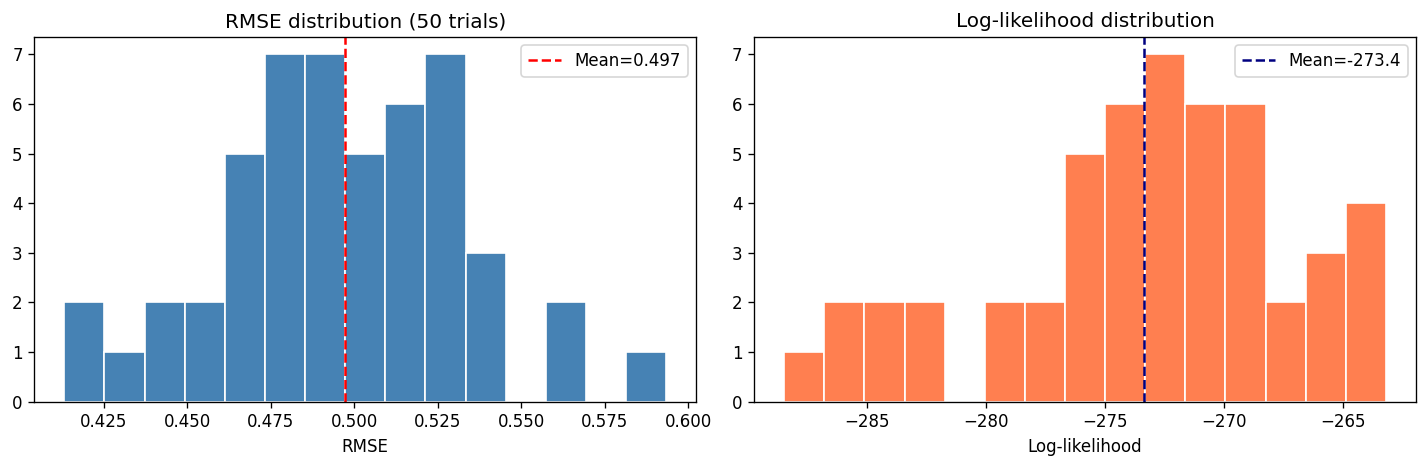

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(rmse_mc, bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(rmse_mc), color='red', linestyle='--', label=f'Mean={np.mean(rmse_mc):.3f}')
axes[0].set_xlabel('RMSE')
axes[0].set_title(f'RMSE distribution ({N_trials} trials)')
axes[0].legend()

axes[1].hist(loglik_mc, bins=15, color='coral', edgecolor='white')
axes[1].axvline(np.mean(loglik_mc), color='navy', linestyle='--', label=f'Mean={np.mean(loglik_mc):.1f}')
axes[1].set_xlabel('Log-likelihood')
axes[1].set_title('Log-likelihood distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3. Effect of N_particles on filtering accuracy

In [28]:
# Fixed dataset: same true states and observations for every run so that
# differences come from particle stochasticity only, not data variation.
model_ref = SimpleLinearGaussianSSM(phi=phi_true, alpha=alpha_true,
                                    sigma=sigma_true, tau=tau_true, seed=0)
states_ref, obs_ref, _ = model_ref.generate_data(150)
obs_ref_1d = obs_ref[:, 0]
true_x_ref = states_ref[:, 0]

N_values = [25, 50, 100, 250, 500, 1000, 2500, 5000, 10000, 20000]
N_reps   = 30   # independent PF runs per N (different RNG seeds → different particle draws)

rmse_by_N   = {n: [] for n in N_values}
loglik_by_N = {n: [] for n in N_values}

for n_part in N_values:
    for rep in range(N_reps):
        pf_ = ParticleFilter(
            model=model_ref, N_particles=n_part, data=obs_ref_1d,
            resample_method=SystematicResampling(seed=rep),
            seed=rep + 10000,
        )
        _, _, _, _, ll = pf_.run_filter()
        rmse_by_N[n_part].append(rmse(true_x_ref, filtered_trajectory(pf_)))
        loglik_by_N[n_part].append(ll)

rmse_mean   = np.array([np.mean(rmse_by_N[n])  for n in N_values])
rmse_std    = np.array([np.std(rmse_by_N[n])   for n in N_values])
loglik_mean = np.array([np.mean(loglik_by_N[n]) for n in N_values])
loglik_std  = np.array([np.std(loglik_by_N[n])  for n in N_values])

print(f"{'N':>6}  {'RMSE mean':>10}  {'RMSE std':>9}  {'loglik mean':>12}  {'loglik std':>10}")
print("-" * 56)
for i, n in enumerate(N_values):
    print(f"{n:>6}  {rmse_mean[i]:>10.4f}  {rmse_std[i]:>9.4f}  "
          f"{loglik_mean[i]:>12.2f}  {loglik_std[i]:>10.4f}")

     N   RMSE mean   RMSE std   loglik mean  loglik std
--------------------------------------------------------
    25      0.5033     0.0180       -291.02      4.0300
    50      0.4830     0.0112       -289.14      2.5767
   100      0.4778     0.0098       -288.92      2.0293
   250      0.4762     0.0083       -288.44      1.4567
   500      0.4758     0.0066       -288.52      1.3986
  1000      0.4767     0.0062       -288.15      1.5889
  2500      0.4775     0.0022       -289.14      0.7835
  5000      0.4775     0.0041       -289.02      0.8507
 10000      0.4788     0.0022       -288.95      0.8007
 20000      0.4782     0.0011       -289.15      0.2778


In [29]:
# true log-likelihood
loglik_true = model_ref.log_likelihood(obs_ref_1d)
print(f"True log-likelihood: {loglik_true:.2f}")

True log-likelihood: -278.79


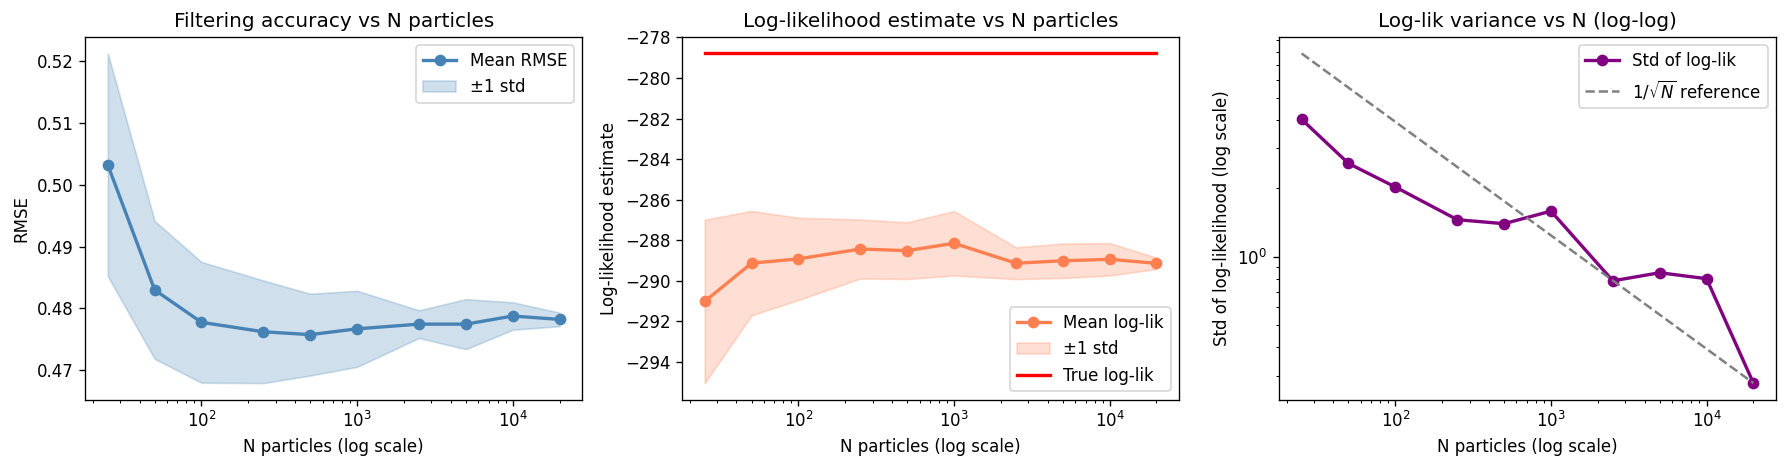

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── RMSE mean ± 1 std ──────────────────────────────────────────────────────
axes[0].semilogx(N_values, rmse_mean, 'o-', color='steelblue', lw=2, label='Mean RMSE')
axes[0].fill_between(N_values, rmse_mean - rmse_std, rmse_mean + rmse_std,
                     alpha=0.25, color='steelblue', label='±1 std')
axes[0].set_xlabel('N particles (log scale)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Filtering accuracy vs N particles')
axes[0].legend()

# ── log-likelihood mean ± 1 std ────────────────────────────────────────────
axes[1].semilogx(N_values, loglik_mean, 'o-', color='coral', lw=2, label='Mean log-lik')
axes[1].fill_between(N_values, loglik_mean - loglik_std, loglik_mean + loglik_std,
                     alpha=0.25, color='coral', label='±1 std')
# plot true log-likelihood of data as a constant line
axes[1].semilogx(N_values, loglik_true * np.ones(len(N_values)), '-', color='red', lw=2, label='True log-lik')
axes[1].set_xlabel('N particles (log scale)')
axes[1].set_ylabel('Log-likelihood estimate')
axes[1].set_title('Log-likelihood estimate vs N particles')
axes[1].legend()

# ── log-likelihood std on log-log (should scale as 1/sqrt(N)) ─────────────
axes[2].loglog(N_values, loglik_std, 'o-', color='purple', lw=2, label='Std of log-lik')
# reference 1/sqrt(N) line anchored at the largest N
ref_scale = loglik_std[-1] * np.sqrt(N_values[-1])
ref_line  = ref_scale / np.sqrt(N_values)
axes[2].loglog(N_values, ref_line, '--', color='gray', lw=1.5, label='$1/\\sqrt{N}$ reference')
axes[2].set_xlabel('N particles (log scale)')
axes[2].set_ylabel('Std of log-likelihood (log scale)')
axes[2].set_title('Log-lik variance vs N (log-log)')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## 4. Noise sensitivity: effect of σ and τ on filtering accuracy

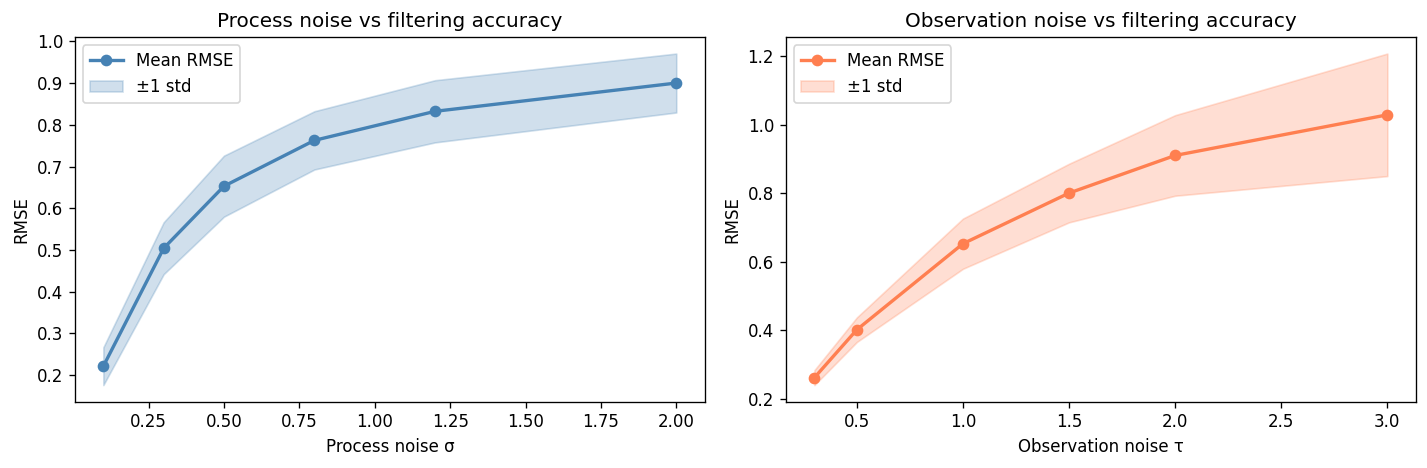

In [ ]:
def mean_and_std_rmse(phi, alpha, sigma, tau, n_trials=15, T=100, N=500):
    errors = []
    for seed in range(n_trials):
        m = SimpleLinearGaussianSSM(phi=phi, alpha=alpha, sigma=sigma, tau=tau, seed=seed)
        s, o, _ = m.generate_data(T)
        pf_ = ParticleFilter(model=m, N_particles=N, data=o[:, 0],
                             resample_method=SystematicResampling(seed=seed + 500))
        pf_.run_filter()
        errors.append(rmse(s[:, 0], filtered_trajectory(pf_)))
    return np.mean(errors), np.std(errors)

sigma_vals = [0.1, 0.3, 0.5, 0.8, 1.2, 2.0, 3.0]
tau_vals   = [0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]

sigma_results = [mean_and_std_rmse(0.9, 1.0, s, 1.0) for s in sigma_vals]
tau_results   = [mean_and_std_rmse(0.9, 1.0, 0.5, t) for t in tau_vals]

sigma_mean, sigma_std = map(np.array, zip(*sigma_results))
tau_mean,   tau_std   = map(np.array, zip(*tau_results))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sigma_vals, sigma_mean, 'o-', color='steelblue', lw=2, label='Mean RMSE')
axes[0].fill_between(sigma_vals, sigma_mean - sigma_std, sigma_mean + sigma_std,
                     alpha=0.25, color='steelblue', label='±1 std')
axes[0].set_xlabel('Process noise σ')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Process noise vs filtering accuracy')
axes[0].legend()

axes[1].plot(tau_vals, tau_mean, 'o-', color='coral', lw=2, label='Mean RMSE')
axes[1].fill_between(tau_vals, tau_mean - tau_std, tau_mean + tau_std,
                     alpha=0.25, color='coral', label='±1 std')
axes[1].set_xlabel('Observation noise τ')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Observation noise vs filtering accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Empirical Relation of N_particles vs Observation noise
Compare mean and variance of RMSE and log-likelihood
Scatter Plot (colored points), 3D plot, or Heatmap
Investigate trade-off between observation noise and number of particles needed to recapture same level of error

In [ ]:
# implement, code

In [ ]:
# result summary

In [ ]:
# plot

---
## 5. Resampling method comparison

In [19]:
resamplers = {
    'Systematic' : SystematicResampling,
    'Stratified' : StratifiedResampling,
    'Residual'   : ResidualResampling,
    'Multinomial': MultinomialResampling,
}

N_rs   = 30
T_rs   = 100
N_part = 500

rmse_rs   = {k: [] for k in resamplers}
loglik_rs = {k: [] for k in resamplers}

for seed in range(N_rs):
    m = SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma=0.5, tau=1.0, seed=seed)
    s, o, _ = m.generate_data(T_rs)
    for name, cls in resamplers.items():
        pf_ = ParticleFilter(model=m, N_particles=N_part, data=o[:, 0],
                             resample_method=cls(seed=seed + 2000), seed=seed + 3000)
        _, ph_, wh_, _, ll = pf_.run_filter()
        rmse_rs[name].append(rmse(s[:, 0], filtered_trajectory(pf_)))
        loglik_rs[name].append(ll)

In [20]:
results = {
    name: (np.mean(rmse_rs[name]), np.std(rmse_rs[name]),
           np.mean(loglik_rs[name]), np.std(loglik_rs[name]))
    for name in resamplers
}

best = {
    0: min(results, key=lambda x: results[x][0]),  # lowest RMSE mean
    1: min(results, key=lambda x: results[x][1]),  # lowest RMSE std
    2: max(results, key=lambda x: results[x][2]),  # highest loglik mean
    3: min(results, key=lambda x: results[x][3]),  # lowest loglik std
}

def star(name, col):
    return '★' if best[col] == name else ' '

print(f"{'Method':<12}  {'RMSE mean':>10}  {'RMSE std':>9}  {'loglik mean':>12}  {'loglik std':>10}")
print('-' * 60)
for name, (rm, rs, lm, ls) in results.items():
    print(f"{name:<12}  {rm:>9.4f}{star(name,0)}  {rs:>8.4f}{star(name,1)}  "
          f"{lm:>11.2f}{star(name,2)}  {ls:>9.2f}{star(name,3)}")

Method         RMSE mean   RMSE std   loglik mean  loglik std
------------------------------------------------------------
Systematic       0.6423★    0.0693       -168.95★       4.03★
Stratified       0.6444     0.0679★      -169.19        4.37 
Residual         0.6450     0.0707       -169.16        4.48 
Multinomial      0.6464     0.0709       -169.07        4.40 


/var/folders/6t/j_420_511zsftkrvyzgx57l80000gn/T/ipykernel_42188/3169042032.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([rmse_rs[n] for n in names], labels=names)
/var/folders/6t/j_420_511zsftkrvyzgx57l80000gn/T/ipykernel_42188/3169042032.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([loglik_rs[n] for n in names], labels=names)


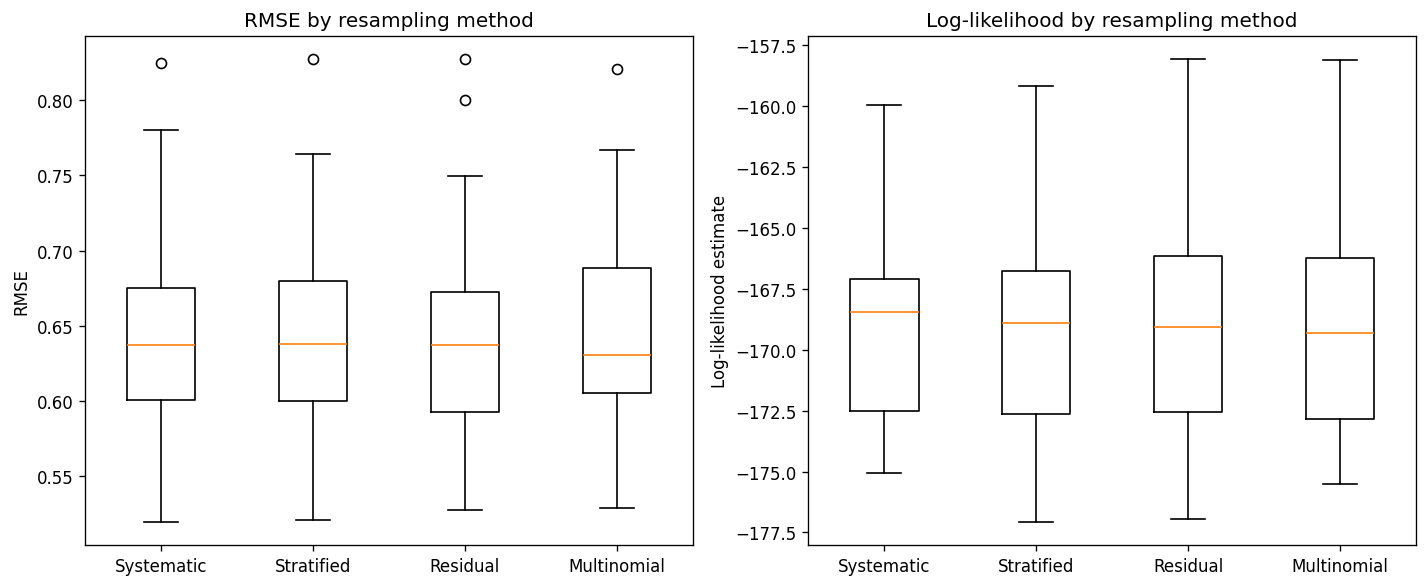

In [21]:
names = list(resamplers.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([rmse_rs[n] for n in names], labels=names)
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE by resampling method')

axes[1].boxplot([loglik_rs[n] for n in names], labels=names)
axes[1].set_ylabel('Log-likelihood estimate')
axes[1].set_title('Log-likelihood by resampling method')

plt.tight_layout()
plt.show()

---
## 6. LinearTSSM — correct vs misspecified filter

Data generated from a model with t-distributed process noise (df=5).  
Compare PF using the correct `LinearTSSM` against a misspecified `SimpleLinearGaussianSSM` filter.

In [22]:
model_t = LinearTSSM(alpha=1.0, tau=1.0, phi=0.9, sigma=0.5, df=5, seed=42)
print(model_t)

T_t = 200
states_t, obs_t, _ = model_t.generate_data(T_t)
obs_t_1d = obs_t[:, 0]
true_x_t = states_t[:, 0]

# correct model
pf_t_correct = ParticleFilter(
    model=LinearTSSM(alpha=1.0, tau=1.0, phi=0.9, sigma=0.5, df=5, seed=1),
    N_particles=2000, data=obs_t_1d,
    resample_method=SystematicResampling(seed=10)
)
_, _, _, _, ll_correct = pf_t_correct.run_filter()
x_correct = filtered_trajectory(pf_t_correct)

# misspecified Gaussian filter
pf_t_misspec = ParticleFilter(
    model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma=0.5, tau=1.0, seed=1),
    N_particles=2000, data=obs_t_1d,
    resample_method=SystematicResampling(seed=10)
)
_, _, _, _, ll_misspec = pf_t_misspec.run_filter()
x_misspec = filtered_trajectory(pf_t_misspec)

print(f"t-SSM  (correct)     loglik={ll_correct:.2f}  RMSE={rmse(true_x_t, x_correct):.4f}")
print(f"Gauss  (misspecified) loglik={ll_misspec:.2f}  RMSE={rmse(true_x_t, x_misspec):.4f}")

LinearTSSM(phi=0.9, alpha=1.0, sigma=0.5, tau=1.0, df=5)
t-SSM  (correct)     loglik=-343.78  RMSE=0.6721
Gauss  (misspecified) loglik=-335.54  RMSE=0.6595


t-SSM   RMSE: 0.7476 ± 0.0761
Gauss   RMSE: 0.7422 ± 0.1521


/var/folders/6t/j_420_511zsftkrvyzgx57l80000gn/T/ipykernel_42188/1558544977.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([rmse_correct_t, rmse_misspec_t],


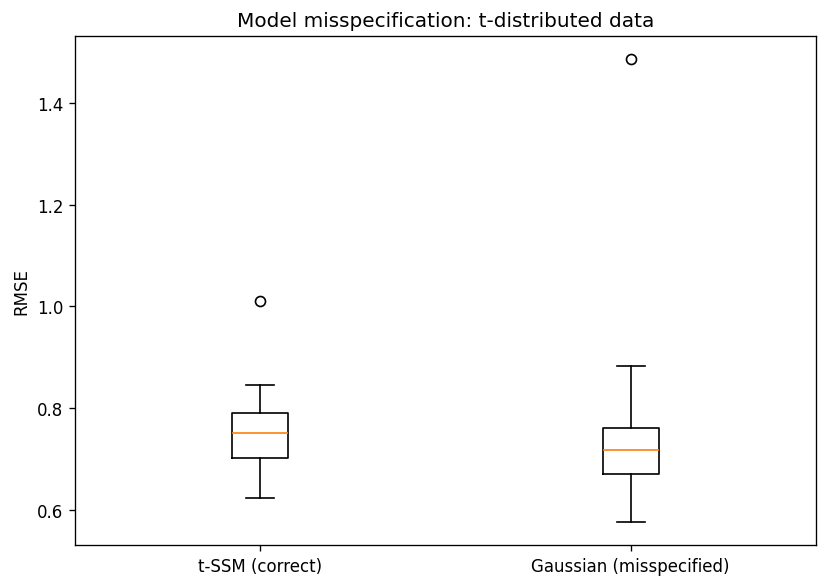

In [23]:
N_t = 30
T_t_mc = 100
N_t_part = 1000

rmse_correct_t  = []
rmse_misspec_t  = []

for seed in range(N_t):
    m_t = LinearTSSM(alpha=1.0, tau=1.0, phi=0.9, sigma=0.5, df=5, seed=seed)
    s_t, o_t, _ = m_t.generate_data(T_t_mc)
    obs_flat = o_t[:, 0]

    pf_c = ParticleFilter(
        model=LinearTSSM(alpha=1.0, tau=1.0, phi=0.9, sigma=0.5, df=5, seed=seed + 100),
        N_particles=N_t_part, data=obs_flat,
        resample_method=SystematicResampling(seed=seed + 200)
    )
    pf_c.run_filter()
    rmse_correct_t.append(rmse(s_t[:, 0], filtered_trajectory(pf_c)))

    pf_m = ParticleFilter(
        model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma=0.5, tau=1.0, seed=seed + 100),
        N_particles=N_t_part, data=obs_flat,
        resample_method=SystematicResampling(seed=seed + 300)
    )
    pf_m.run_filter()
    rmse_misspec_t.append(rmse(s_t[:, 0], filtered_trajectory(pf_m)))

print(f"t-SSM   RMSE: {np.mean(rmse_correct_t):.4f} ± {np.std(rmse_correct_t):.4f}")
print(f"Gauss   RMSE: {np.mean(rmse_misspec_t):.4f} ± {np.std(rmse_misspec_t):.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([rmse_correct_t, rmse_misspec_t],
           labels=['t-SSM (correct)', 'Gaussian (misspecified)'])
ax.set_ylabel('RMSE')
ax.set_title('Model misspecification: t-distributed data')
plt.tight_layout()
plt.show()

---
## 7. LinearARMASSM (correct vs misspecified filter)

Latent process: $x_t = c + \phi x_{t-1} + \nu_t + \theta_1 \nu_{t-1} + \theta_2 \nu_{t-2} + \theta_3 \nu_{t-3}$.  
Markov state: $s_t = [x_t,\, \nu_{t-1},\, \nu_{t-2}, \, \nu_{t-3}]^\top$. PF estimates the full 4D state; we compare on the $x_t$ component.

In [24]:
model_arma = LinearARMASSM(
    phi=0.8, alpha=1.0, c=0.0,
    theta_1=0.3, theta_2=0.2, theta_3=0.1,
    sigma=0.5, tau=1.0, seed=42
)
print(model_arma)

T_arma = 200
states_arma, obs_arma, _ = model_arma.generate_data(T_arma)
obs_arma_1d = obs_arma[:, 0]
true_x_arma = states_arma[:, 0]

pf_arma = ParticleFilter(
    model=model_arma, N_particles=3000, data=obs_arma_1d,
    resample_method=SystematicResampling(seed=5)
)

pf_arma_misspec = ParticleFilter(
    model=SimpleLinearGaussianSSM(phi=0.8, alpha=1.0, sigma=0.5, tau=1.0, seed=42),
    N_particles=3000, data=obs_arma_1d,
    resample_method=SystematicResampling(seed=5)
)

_, ph_arma, wh_arma, rsh_arma, loglik_arma = pf_arma.run_filter()
_, ph_arma_misspec, wh_arma_misspec, rsh_arma_misspec, loglik_arma_misspec = pf_arma_misspec.run_filter()

x_hat_arma = filtered_trajectory(pf_arma, state_idx=0)
x_hat_arma_misspec = filtered_trajectory(pf_arma_misspec, state_idx=0)

print(f"ARMA PF log-likelihood: {loglik_arma:.2f}")
print(f"RMSE (x_t component)  : {rmse(true_x_arma, x_hat_arma):.4f}")
print(f"Resample steps        : {sum(rsh_arma)} / {T_arma}")
print("---"*30)
print("Misspecified linear model results:")
print(f"ARMA PF log-likelihood: {loglik_arma_misspec:.2f}")
print(f"RMSE (x_t component)  : {rmse(true_x_arma, x_hat_arma_misspec):.4f}")
print(f"Resample steps        : {sum(rsh_arma_misspec)} / {T_arma}")

LinearARMASSM(phi=0.8, alpha=1.0, c=0.0, theta_1=0.3, theta_2=0.2, theta_3=0.1, sigma=0.5, tau=1.0)
ARMA PF log-likelihood: -345.31
RMSE (x_t component)  : 0.6467
Resample steps        : 35 / 200
------------------------------------------------------------------------------------------
Misspecified linear model results:
ARMA PF log-likelihood: -332.89
RMSE (x_t component)  : 0.6265
Resample steps        : 27 / 200


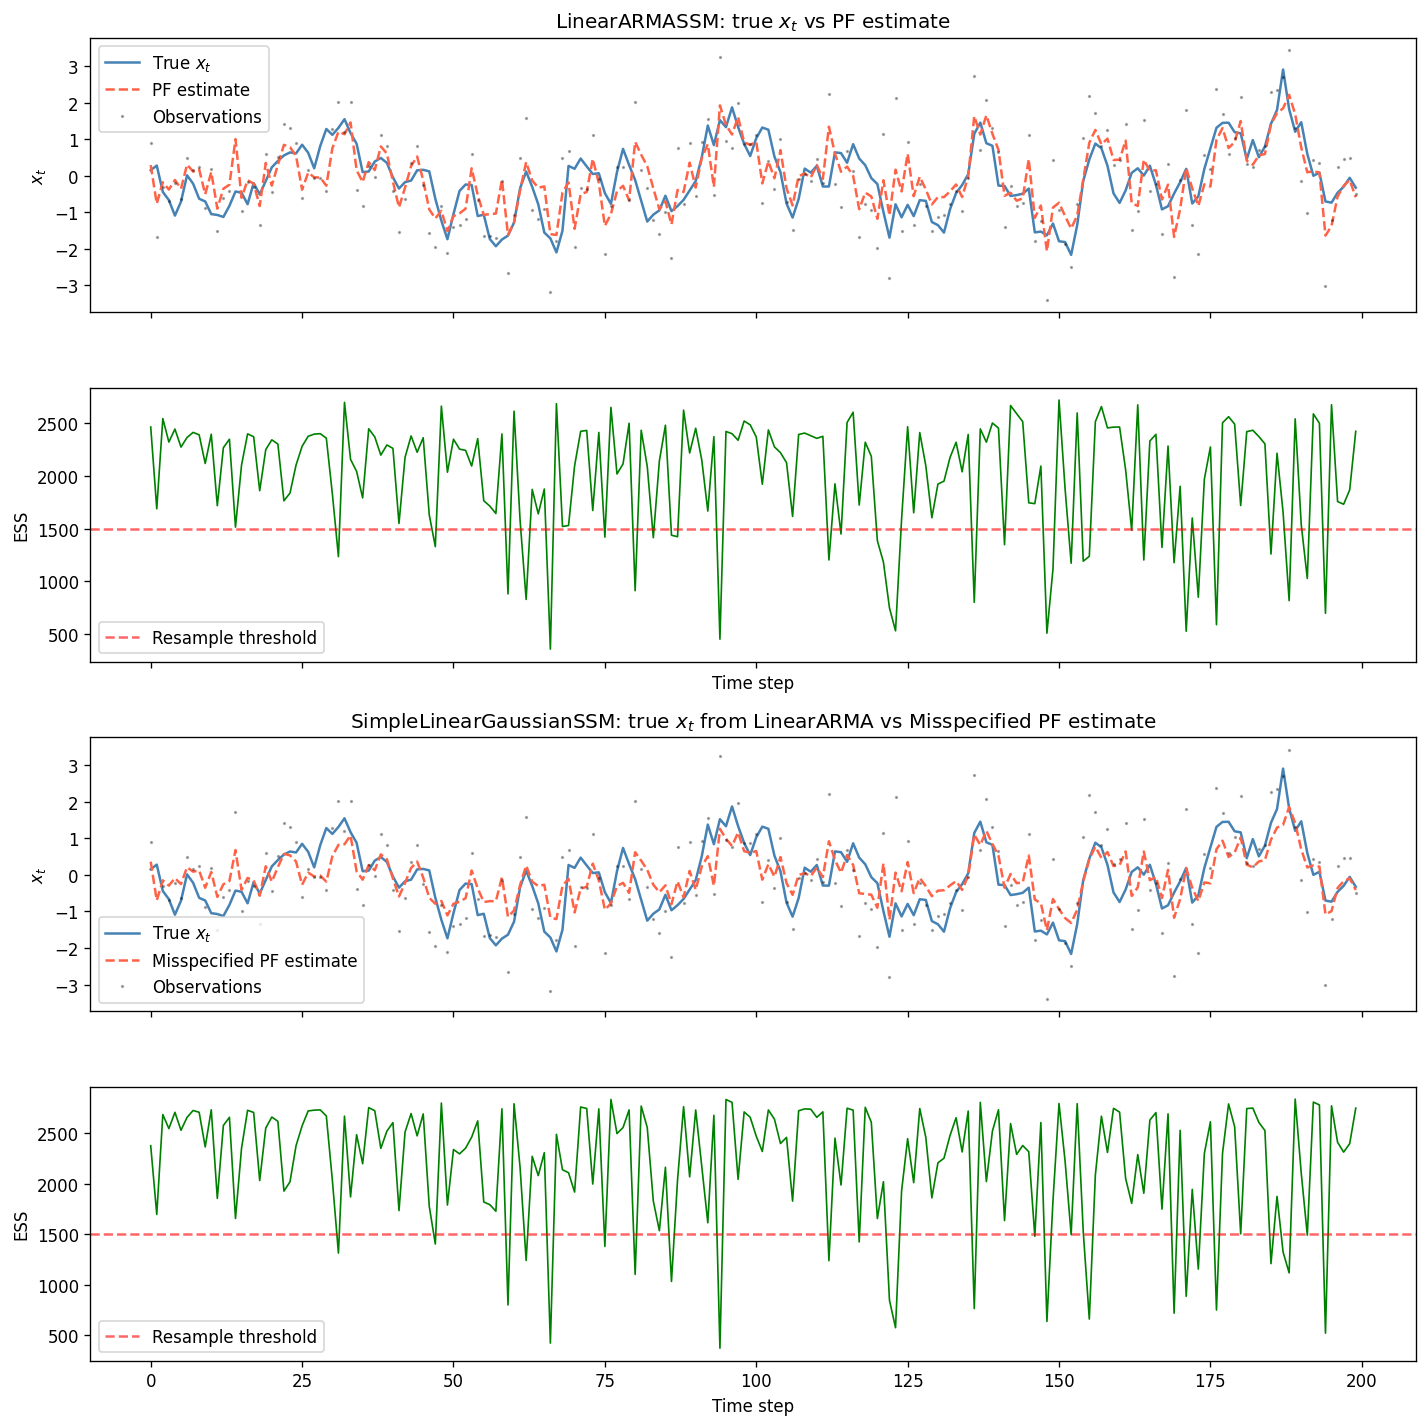

In [25]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(true_x_arma,  label='True $x_t$', color='steelblue', lw=1.5)
axes[0].plot(x_hat_arma,   label='PF estimate', color='tomato', lw=1.5, linestyle='--')
axes[0].plot(obs_arma_1d,  '.', color='black', markersize=2, alpha=0.3, label='Observations')
axes[0].set_ylabel('$x_t$')
axes[0].legend()
axes[0].set_title('LinearARMASSM: true $x_t$ vs PF estimate')

ess_arma = ess_trajectory(pf_arma)
axes[1].plot(ess_arma, color='green', lw=1)
axes[1].axhline(pf_arma.resample_threshold * pf_arma.N_particles,
                color='red', linestyle='--', alpha=0.6, label='Resample threshold')
axes[1].set_ylabel('ESS')
axes[1].set_xlabel('Time step')
axes[1].legend()

axes[2].plot(true_x_arma,  label='True $x_t$', color='steelblue', lw=1.5)
axes[2].plot(x_hat_arma_misspec, label='Misspecified PF estimate', color='tomato', lw=1.5, linestyle='--')
axes[2].plot(obs_arma_1d,  '.', color='black', markersize=2, alpha=0.3, label='Observations')
axes[2].set_ylabel('$x_t$')
axes[2].legend()
axes[2].set_title('SimpleLinearGaussianSSM: true $x_t$ from LinearARMA vs Misspecified PF estimate')

ess_arma_misspec = ess_trajectory(pf_arma_misspec)
axes[3].plot(ess_arma_misspec, color='green', lw=1)
axes[3].axhline(pf_arma.resample_threshold * pf_arma.N_particles,
                color='red', linestyle='--', alpha=0.6, label='Resample threshold')
axes[3].set_ylabel('ESS')
axes[3].set_xlabel('Time step')
axes[3].legend()

plt.tight_layout()
plt.show()

In [26]:
# Comparing RMSE of the correct and missepcified models for ARMA

print(f"RMSE correct (x_t component)       : {rmse(true_x_arma, x_hat_arma):.4f}")
print(f"RMSE misspecified (x_t component)  : {rmse(true_x_arma, x_hat_arma_misspec):.4f}")


RMSE correct (x_t component)       : 0.6467
RMSE misspecified (x_t component)  : 0.6265


In [27]:
# import from time_series_analysis.py to analyze ARMA(p,q) coefficients
from time_series_analysis import compare_arima_models

compare_arima_models(
    y = obs_arma_1d,
    p_values=range(0, 5),
    d_values=(0,),
    q_values=range(0, 5),
    max_ljungbox_lag=10,
    trend="n",
)

,order,p,d,q,aic,bic,hqic,loglik,ljungbox_p,converged
0,"(2, 0, 0)",2,0,0,641.427743,651.292545,645.420687,-317.713872,0.994613,True
1,"(1, 0, 1)",1,0,1,642.637447,652.502248,646.630390,-318.318723,0.975698,True
2,"(0, 0, 2)",0,0,2,642.712240,652.561851,646.699436,-318.356120,0.892628,True
3,"(3, 0, 0)",3,0,0,641.167673,654.300488,646.483934,-316.583836,0.994540,True
4,"(1, 0, 2)",1,0,2,641.492882,654.625697,646.809144,-316.746441,0.992066,True
5,"(0, 0, 3)",0,0,3,641.521730,654.634189,646.830282,-316.760865,0.936283,True
6,"(0, 0, 4)",0,0,4,639.140025,655.505023,645.766019,-314.570012,0.994221,True
7,"(2, 0, 1)",2,0,1,643.351924,656.504992,648.675849,-317.675962,0.994944,True
8,"(4, 0, 0)",4,0,0,640.321285,656.711858,646.956974,-315.160642,0.998194,True
9,"(1, 0, 3)",1,0,3,640.992376,657.382949,647.628065,-315.496188,0.995722,True


---
## Next steps

- **Kalman filter MLE**: for `SimpleLinearGaussianSSM`, the marginal log-likelihood is analytically tractable via the Kalman filter. Implement `kalman_log_likelihood(params, observations)` and optimize with `scipy.optimize.minimize`.
- **PMMH**: use the PF log-likelihood estimate as an unbiased estimator inside a Metropolis–Hastings loop to do Bayesian inference over `(phi, sigma, tau)`. The PF is already returning `loglik`.
- **RBPF / Kim filter**: for the regime-switching model in `src/models/regime_switching.py`, the Rao-Blackwellized PF marginalizes out the continuous state analytically while sampling discrete regimes.